### Полиномиальная регрессия. Как из линейной регрессии сделать криволинейную?

Линейная модель (прямая линия):
![img](http://neerc.ifmo.ru/wiki/images/f/f0/Linear_regression_example.png)

***А что если нельзя провести оптимальную прямую линию?***
<a href="https://ibb.co/XXBwvBP"><img src="https://i.ibb.co/Wn9TY9X/9.jpg" alt="9" border="0"></a>

Нужно использовать нелинейную модель:
![img](https://www.machinelearningmastery.ru/img/0-399364-636329.png)

***Модель полиномиальной регрессии (polynomial regression)*** - это обобщенная линейная модель с параметризованной степенью многочлена.

![img](https://russianblogs.com/images/753/361716febc5a15ae65cdba4394db1f69.png)

Многочлен 1-й степени:

$$ y=ax+b $$ 

Многочлен 3-й степени:
$$ y = ax^3 + bx^2 + cx + d $$

Несмотря на то, что мы можем использовать полиномиальную регрессию для моделирования нелинейных связей, она по-прежнему рассматривается как модель множественной линейной регрессии, ввиду 
линейных коэффициентов регрессии.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures  # Класс преобразователь

[Ссылка на документацию](https://scikit-learn.org/stable/modules/preprocessing.html#polynomial-features)

In [2]:
# Моделируем данные
X = np.array([258.0, 270.0, 294.0, 320.0, 342.0, 368.0, 396.0, 446.0, 480.0, 586.0])[:, np.newaxis]
y = np.array([236.4, 234.4, 252.8, 298.6, 314.2, 342.2, 360.8, 368.0, 391.2, 390.8])

In [3]:
X

array([[258.],
       [270.],
       [294.],
       [320.],
       [342.],
       [368.],
       [396.],
       [446.],
       [480.],
       [586.]])

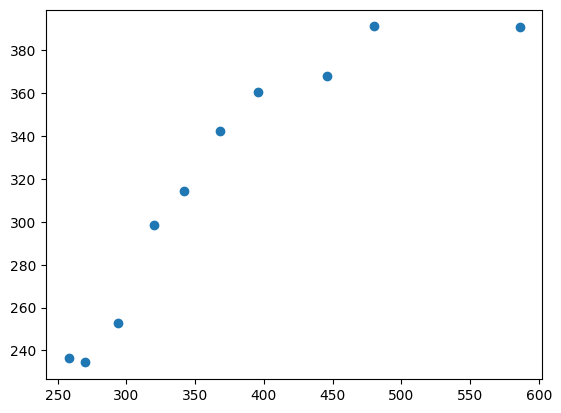

In [4]:
plt.scatter(X, y) 

In [5]:
lr = LinearRegression() # Линейная регрессия
lr.fit(X, y) # Обучим линейную регрессию

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
X_ = np.arange(250, 600, 10)[:, np.newaxis] # Точки для предсказания
y_lr = lr.predict(X_) # Предсказываем y для линейной регрессии

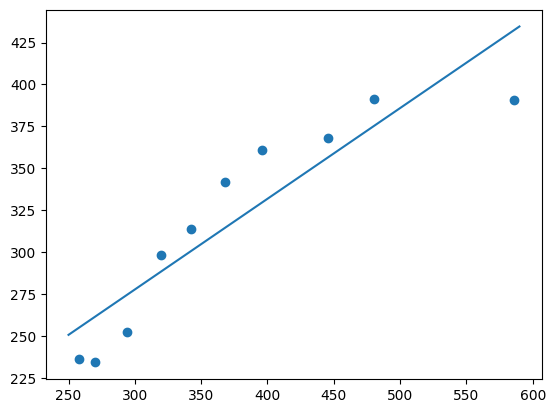

In [7]:
plt.scatter(X, y) 
plt.plot(X_, y_lr) 

In [8]:
pr = LinearRegression() # Полиномиальная регрессия

In [9]:
quadratic = PolynomialFeatures(degree=2)
X_quad = quadratic.fit_transform(X)       # Преобразуем данные

In [10]:
X_quad

array([[1.00000e+00, 2.58000e+02, 6.65640e+04],
       [1.00000e+00, 2.70000e+02, 7.29000e+04],
       [1.00000e+00, 2.94000e+02, 8.64360e+04],
       [1.00000e+00, 3.20000e+02, 1.02400e+05],
       [1.00000e+00, 3.42000e+02, 1.16964e+05],
       [1.00000e+00, 3.68000e+02, 1.35424e+05],
       [1.00000e+00, 3.96000e+02, 1.56816e+05],
       [1.00000e+00, 4.46000e+02, 1.98916e+05],
       [1.00000e+00, 4.80000e+02, 2.30400e+05],
       [1.00000e+00, 5.86000e+02, 3.43396e+05]])

In [11]:
pr.fit(X_quad, y) # Обучаем полиномиальную регрессию

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pr = pr.predict(quadratic.fit_transform(X_)) # Предсказываем y для полиномиальной регрессии

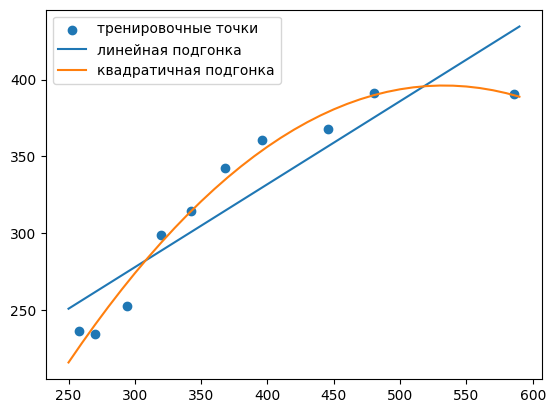

In [13]:
plt.scatter(X, y, label = 'тренировочные точки') 
plt.plot(X_, y_lr, label = 'линейная подгонка') 
plt.plot(X_, y_pr, label = 'квадратичная подгонка') 
plt.legend(loc='upper left') 
plt.show()

Задание 1. Оцените полученные модели с помощью коэффициента детерминации и MSE. Что можно сказать о качестве моделей?

Замечание!!! mean_squared_error принимает 1-м аргументом истинные значения y, а 2-м предсказанные (см. документацию!). 
Получается, для линейной регрессии:

In [14]:
from sklearn.metrics import mean_squared_error

# Для наших синих точек 

y_pred = lr.predict(X)
mse_linear = mean_squared_error(y, y_pred)
print('Для линейной регрессии:', mse_linear)

# Аналогично выполните для полиномиальной модели и сравните результат

# Для полиномиальной регрессии
y_pred_poly = pr.predict(X_quad)
mse_poly = mean_squared_error(y, y_pred_poly)
print(f'Для полиномиальной регрессии: {mse_poly:.2f}')

# Сравнение результатов
print(f'\nРазница (линейная - полиномиальная): {mse_linear - mse_poly:.2f}')
if mse_poly < mse_linear:
    print('✓ Полиномиальная модель лучше (меньше ошибка)')
else:
    print('✓ Линейная модель лучше (меньше ошибка)')


Для линейной регрессии: 569.7796663183207
Для полиномиальной регрессии: 61.33

Разница (линейная - полиномиальная): 508.45
✓ Полиномиальная модель лучше (меньше ошибка)


Задание 2. Постройте полиномиальную модель, описывающую следующую зависимость:

Для линейной регрессии: 44.16714270349082
Для полиномиальной регрессии: 29.79

Разница (линейная - полиномиальная): 14.37
✓ Полиномиальная модель лучше (меньше ошибка)


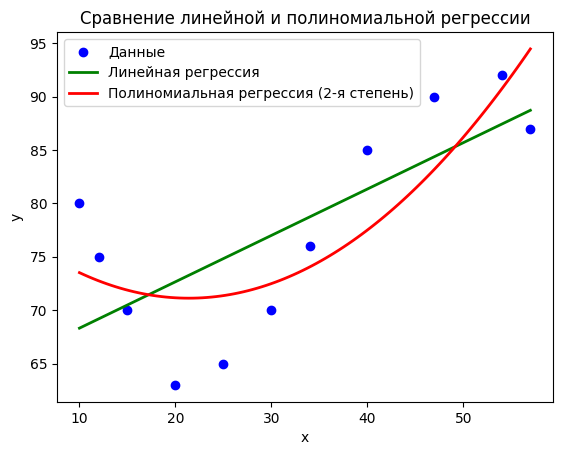

In [15]:
x = np.array([10, 12, 15, 20, 25, 30, 34, 40, 47, 54, 57])[:, np.newaxis]
y = np.array([80, 75, 70, 63, 65, 70, 76, 85, 90, 92, 87 ])

# ===== ЛИНЕЙНАЯ РЕГРЕССИЯ =====
lr = LinearRegression()
lr.fit(x, y)
y_pred = lr.predict(x)
mse_linear = mean_squared_error(y, y_pred)
print('Для линейной регрессии:', mse_linear)

# ===== ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (2-я степень) =====
poly_features = PolynomialFeatures(degree=2)
X_quad = poly_features.fit_transform(x)

pr = LinearRegression()
pr.fit(X_quad, y)
y_pred_poly = pr.predict(X_quad)
mse_poly = mean_squared_error(y, y_pred_poly)
print(f'Для полиномиальной регрессии: {mse_poly:.2f}')

# ===== СРАВНЕНИЕ РЕЗУЛЬТАТОВ =====
print(f'\nРазница (линейная - полиномиальная): {mse_linear - mse_poly:.2f}')
if mse_poly < mse_linear:
    print('✓ Полиномиальная модель лучше (меньше ошибка)')
else:
    print('✓ Линейная модель лучше (меньше ошибка)')

# ===== ВИЗУАЛИЗАЦИЯ ОБЕИХ МОДЕЛЕЙ =====
x_sorted = np.linspace(x.min(), x.max(), 100)[:, np.newaxis]
y_linear = lr.predict(x_sorted)

x_quad_sorted = poly_features.transform(x_sorted)
y_poly = pr.predict(x_quad_sorted)

plt.scatter(x, y, label='Данные', color='blue')
plt.plot(x_sorted, y_linear, label='Линейная регрессия', color='green', linewidth=2)
plt.plot(x_sorted, y_poly, label='Полиномиальная регрессия (2-я степень)', color='red', linewidth=2)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение линейной и полиномиальной регрессии')
plt.show()

Задание 3. Какую степень полинома вы использовали? Попробуйте изменить степень полинома, например, на 2, 5, 15? Как меняется результат?

Степень полинома 2: MSE = 29.7942
Степень полинома 5: MSE = 0.6219
Степень полинома 15: MSE = 11.1297

--- СРАВНЕНИЕ ---
Степень 2: MSE = 29.7942
Степень 5: MSE = 0.6219
Степень 15: MSE = 11.1297

✓ Лучшая степень: 5 (MSE = 0.6219)


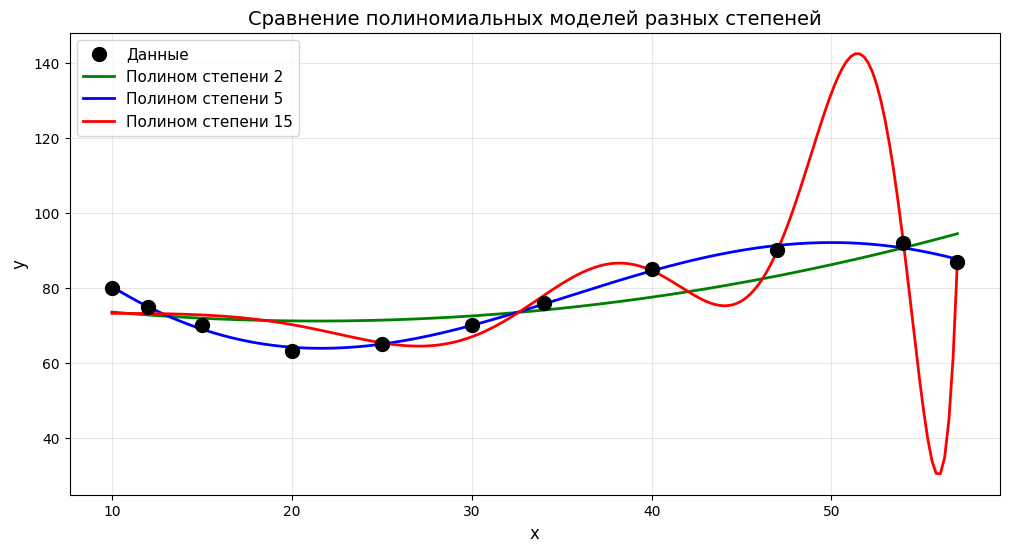

In [16]:
degrees = [2, 5, 15]
results = {}

# ===== ЦИКЛ ДЛЯ РАЗНЫХ СТЕПЕНЕЙ =====
for degree in degrees:
    # Создаём полиномиальные признаки
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(x)
    
    # Обучаем модель
    model = LinearRegression()
    model.fit(X_poly, y)
    
    # Делаем предсказания
    y_pred = model.predict(X_poly)
    
    # Вычисляем MSE
    mse = mean_squared_error(y, y_pred)
    results[degree] = mse
    
    print(f'Степень полинома {degree}: MSE = {mse:.4f}')

# ===== АНАЛИЗ РЕЗУЛЬТАТОВ =====
print('\n--- СРАВНЕНИЕ ---')
for degree in degrees:
    print(f'Степень {degree}: MSE = {results[degree]:.4f}')

best_degree = min(results, key=results.get)
print(f'\n✓ Лучшая степень: {best_degree} (MSE = {results[best_degree]:.4f})')
# ===== ВИЗУАЛИЗАЦИЯ =====
x_smooth = np.linspace(x.min(), x.max(), 200)[:, np.newaxis]

plt.figure(figsize=(12, 6))
plt.scatter(x, y, s=100, label='Данные', color='black', zorder=5)

colors = ['green', 'blue', 'red']
for degree, color in zip(degrees, colors):
    poly_features = PolynomialFeatures(degree=degree)
    X_poly_smooth = poly_features.fit_transform(x_smooth)
    
    model = LinearRegression()
    model.fit(poly_features.fit_transform(x), y)
    
    y_smooth = model.predict(X_poly_smooth)
    plt.plot(x_smooth, y_smooth, label=f'Полином степени {degree}', 
             color=color, linewidth=2)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Сравнение полиномиальных моделей разных степеней', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()
